# CS6580 - Sprint 1

## Team Grapefruit

*Weber State University*

In [19]:
# Imports and global definitions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from patsy import dmatrix
import os

interim_path = "https://connorwtech.com/resources/downloads/interim/"
processed_path = "https://connorwtech.com/resources/downloads/processed/"

pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


In [20]:
# Data Cleaning (not necessary once processed files are redone)

import pandas as pd
import numpy as np
import os

# This program should output locally then user must upload to server manually for security reasons

interim_path = "https://connorwtech.com/resources/downloads/interim/"

# 1.1 Load datasets

N   = pd.read_csv(interim_path + "Natality_2010_2020_interim.csv")

C10 = pd.read_csv(
    interim_path + "/cc-est2019-alldata_interim.csv",
    encoding="latin1"
)

C20 = pd.read_csv(
    interim_path + "/cc-est2023-alldata_interim.csv",
    encoding="latin1"
)

P   = pd.read_csv(interim_path + "/countypres_2000-2024_interim.csv")


# 1.2a1 Natality Preprocessing

# Clean county_code integer column
N["county_code"] = N["County Code"].astype("Int64")

# Rows with unidentified counties
mask_unidentified = (
    N["County"].astype(str).str.strip().str.lower().str.startswith("unidentified")
    | (N["county_code"] % 1000 == 999)
)

# Keep identified rows only
N_clean = N.loc[~mask_unidentified & N["Year"].isin([2010, 2020])].copy()
N_clean["Year"] = N_clean["Year"].astype(int)

# Create common county code
N_clean["county_code"] = N_clean["County Code"].astype("Int64")
N_clean["fips"] = N_clean["county_code"].astype(str).str.zfill(5)


# 1.2a2 Natality Pivoting (one row per county)

N_wide = (
    N_clean
    .pivot_table(
        index="fips",
        columns="Year",
        values=["Birth Rate", "Births", "Total Population"],
        aggfunc="mean"
    )
)

# Flatten column names
N_wide.columns = [
    f"{var.lower().replace(' ', '_')}_{year}"
    for (var, year) in N_wide.columns
]

N_wide = N_wide.reset_index()


# 1.2a3 Natatlity Final

# Counties were included in the analysis only if complete natality data were available for both 2010 and 2020, excluding "Unidentified Counties"

df_N = N_wide.dropna(
    subset=["birth_rate_2010", "birth_rate_2020"]
).copy()

# 1.2b1 Census Preprocessing

# Census AGEGRP → age-band suffix mapping
AGEGRP_TO_SUFFIX = {
    0:  "0000",  # Total population (all ages)
    1:  "0004",  # Ages 0–4
    2:  "0509",  # Ages 5–9
    3:  "1014",  # Ages 10–14
    4:  "1519",  # Ages 15–19
    5:  "2024",  # Ages 20–24
    6:  "2529",  # Ages 25–29
    7:  "3034",  # Ages 30–34
    8:  "3539",  # Ages 35–39
    9:  "4044",  # Ages 40–44
    10: "4549",  # Ages 45–49
    11: "5054",  # Ages 50–54
    12: "5559",  # Ages 55–59
    13: "6064",  # Ages 60–64
    14: "6569",  # Ages 65–69
    15: "7074",  # Ages 70–74
    16: "7579",  # Ages 75–79
    17: "8084",  # Ages 80–84
    18: "8599"   # Ages 85+ (labeled 85–99 for naming consistency)
}

c_agegrps_keep = [4, 5, 6, 7, 8]  # 15–19, 20–24, 25–29, 30–34, 35–39

c_cols_keep = [
    "fips",
    "AGEGRP",
    "TOT_POP",
    "TOT_FEMALE",
    "WA_FEMALE",
    "BA_FEMALE",
    "H_FEMALE",
    "NHWA_FEMALE", # Non-Hispanic White Female
    "NHBA_FEMALE"  # Non-Hispanic Black Female
]

def prep_census(df, name):
    # Build canonical join key
    df = df.copy()
    df["fips"] = df["STATE"].astype(str).str.zfill(2) + df["COUNTY"].astype(str).str.zfill(3)

    # Ensure AGEGRP is clean int for filtering/pivoting
    df["AGEGRP"] = df["AGEGRP"].astype(int)

    # Column existence check
    missing = [c for c in c_cols_keep if c not in df.columns]
    if missing:
        raise KeyError(f"{name}: Missing expected columns: {missing}")

    # Filter to chosen age groups and columns
    out = df.loc[df["AGEGRP"].isin(c_agegrps_keep), c_cols_keep].copy()

    # Optional: sort for predictable merges/pivots
    out = out.sort_values(["fips", "AGEGRP"]).reset_index(drop=True)

    return out

C10_ltd = prep_census(C10, "C10")
C20_ltd = prep_census(C20, "C20")



# 1.2b2 Census Pivoting

def census_to_wide(df_long, vars_to_widen, age_map, name):
    tmp = df_long.copy()
    tmp["age_suffix"] = tmp["AGEGRP"].map(age_map)

    # Safety check: ensure mapping covered all rows
    if tmp["age_suffix"].isna().any():
        missing = sorted(tmp.loc[tmp["age_suffix"].isna(), "AGEGRP"].unique().tolist())
        raise ValueError(f"{name}: AGEGRP values missing from mapping: {missing}")

    wide = tmp.pivot(index="fips", columns="age_suffix", values=vars_to_widen)

    # Flatten (var, age) -> var_age
    wide.columns = [f"{var}_{age}" for (var, age) in wide.columns]
    wide = wide.reset_index()

    return wide

# Columns to widen = everything in c_cols_keep except the keys
vars_to_widen = [c for c in c_cols_keep if c not in ("fips", "AGEGRP")]

wanted_ages = [AGEGRP_TO_SUFFIX[a] for a in c_agegrps_keep]

df_C10 = census_to_wide(C10_ltd, vars_to_widen, AGEGRP_TO_SUFFIX, "C10")
df_C20 = census_to_wide(C20_ltd, vars_to_widen, AGEGRP_TO_SUFFIX, "C20")

# Enforce consistent column order (optional but recommended)
wanted_cols = ["fips"] + [f"{v}_{a}" for v in vars_to_widen for a in wanted_ages]
df_C10 = df_C10[wanted_cols]
df_C20 = df_C20[wanted_cols]



# 1.2c1 Presidential preprocessing

years_baseline = [2008, 2012]
year_actual = 2020
years_keep = years_baseline + [year_actual]

# Work on a copy
Pp = P.copy()

# Keep only years of interest (your file already only has these, but safe)
Pp = Pp.loc[Pp["year"].isin(years_keep)].copy()

# Drop non-county rows (missing county_fips) BEFORE building fips
Pp = Pp.dropna(subset=["county_fips"]).copy()

# Canonical 5-digit FIPS
Pp["county_fips"] = Pp["county_fips"].astype(int)
Pp["fips"] = Pp["county_fips"].astype(str).str.zfill(5)

# Keep only needed columns
Pp = Pp[["fips", "year", "candidatevotes", "totalvotes"]].copy()

# Collapse to one row per county-year (defensive)
P_county_year = (
    Pp.groupby(["fips", "year"], as_index=False)
      .agg({"candidatevotes": "sum", "totalvotes": "max"})
)

# Democratic vote share
P_county_year["dem_share"] = P_county_year["candidatevotes"] / P_county_year["totalvotes"]

# Baseline partisan alignment (average of 2008 & 2012)
dem2010 = (
    P_county_year.loc[P_county_year["year"].isin(years_baseline)]
                 .groupby("fips", as_index=False)["dem_share"]
                 .mean()
                 .rename(columns={"dem_share": "dem2010"})
)

# Contemporary partisan alignment (2020)
dem2020 = (
    P_county_year.loc[P_county_year["year"] == year_actual, ["fips", "dem_share"]]
                 .rename(columns={"dem_share": "dem2020"})
)


# 1.2c2 Presidential final

#County political alignment was measured using Democratic vote share.
#Baseline partisan alignment (dem2010) was calculated as the average Democratic vote share across the 2008 and 2012 presidential elections.
#Contemporary political alignment (dem2020) reflects Democratic vote share in the 2020 presidential election.
#Vote shares were calculated as the proportion of total county-level presidential votes cast for the Democratic candidate.

# Final political dataset
# Retain only counties with both baseline (2008–2012) and 2020 data
df_P = dem2010.merge(dem2020, on="fips", how="inner")


# 1.3 Final datasets

common_fips = (
    set(df_C10["fips"])
    & set(df_C20["fips"])
    & set(df_N["fips"])
    & set(df_P["fips"])
)
common_fips = sorted(common_fips)

# Filter each dataset
C10_c = df_C10[df_C10["fips"].isin(common_fips)].copy()
C20_c = df_C20[df_C20["fips"].isin(common_fips)].copy()
N_c   = df_N[df_N["fips"].isin(common_fips)].copy()
P_c   = df_P[df_P["fips"].isin(common_fips)].copy()

# Adding suffixes to columns to show origin
P_c.rename(columns=lambda x: f"{x}_P" if x != "fips" else x, inplace=True)
N_c.rename(columns=lambda x: f"{x}_N" if x != "fips" else x, inplace=True)
C20_c.rename(columns=lambda x: f"{x}_C" if x != "fips" else x, inplace=True)
C10_c.rename(columns=lambda x: f"{x}_C" if x != "fips" else x, inplace=True)

# Consistent ordering
for d in (C10_c, C20_c, N_c, P_c):
    d.sort_values("fips", inplace=True)
    d.reset_index(drop=True, inplace=True)

df_A = (
    C10_c
    .merge(P_c[["fips", "dem2010_P"]], on="fips", how="inner")
    .merge(
        N_c[["fips", "birth_rate_2010_N", "births_2010_N", "birth_rate_2020_N", "births_2020_N"]],
        on="fips",
        how="inner"
    )
)

df_B = (
    C20_c
    .merge(P_c[["fips", "dem2020_P"]], on="fips", how="inner")
    .merge(
        N_c[["fips", "birth_rate_2020_N", "births_2020_N"]],
        on="fips",
        how="inner"
    )
)

In [21]:
# Load datasets

#df_A = pd.read_csv(processed_path + 'df_A.csv')

## Data Transformation 1 (Age / Race Combos)

In [22]:
# Combine female age groups by race

df_A["NHWA_FEMALE_2034_share_X1"] = (
    df_A["NHWA_FEMALE_2024_C"] + df_A["NHWA_FEMALE_2529_C"] + df_A["NHWA_FEMALE_3034_C"]
    ) / (
    df_A["TOT_FEMALE_2024_C"] + df_A["TOT_FEMALE_2529_C"] + df_A["TOT_FEMALE_3034_C"])

df_A["NHBA_FEMALE_2034_share_X1"] = (
    df_A["NHBA_FEMALE_2024_C"] + df_A["NHBA_FEMALE_2529_C"] + df_A["NHBA_FEMALE_3034_C"]
    ) / (
    df_A["TOT_FEMALE_2024_C"] + df_A["TOT_FEMALE_2529_C"] + df_A["TOT_FEMALE_3034_C"])

df_A["H_FEMALE_2034_share_X1"] = (
    df_A["H_FEMALE_2024_C"] + df_A["H_FEMALE_2529_C"] + df_A["H_FEMALE_3034_C"]
    ) / (
    df_A["TOT_FEMALE_2024_C"] + df_A["TOT_FEMALE_2529_C"] + df_A["TOT_FEMALE_3034_C"])

## Data Transformation 2 (Race categories)

In [23]:
# Create race categories (default "Mixed")

df_A["race_category"] = "Mixed"

df_A.loc[df_A["NHWA_FEMALE_2034_share_X1"] >= 0.6, "race_category"] = "White"
df_A.loc[df_A["NHBA_FEMALE_2034_share_X1"] >= 0.6, "race_category"] = "Black"
df_A.loc[df_A["H_FEMALE_2034_share_X1"] >= 0.6, "race_category"] = "Hispanic"

## Data Transformation 3 (Regimes)

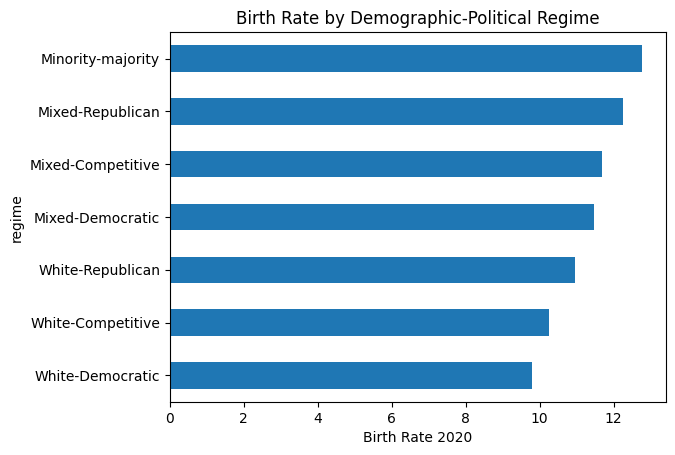

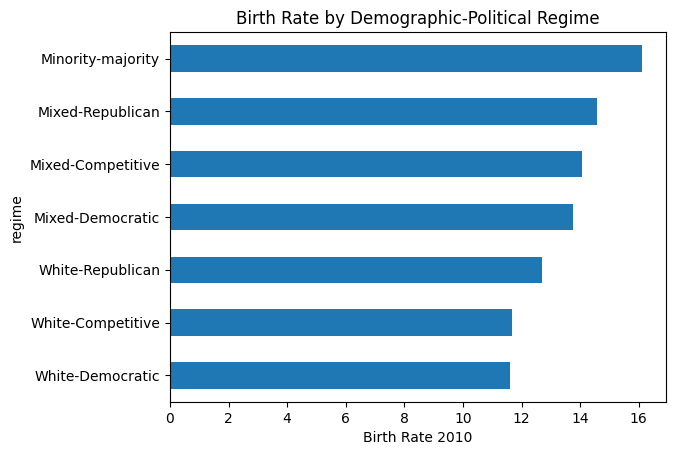

In [24]:
# Create "regime" variable by combining political preference and race categories (default "Minority-majority")

df_A["regime"] = "Minority-majority"

# White-majority
white_mask = df_A["NHWA_FEMALE_2034_share_X1"] >= 0.6

# Mixed
mixed_mask = df_A["race_category"] == "Mixed"

# Political classification
df_A["pol_group"] = "Competitive"
df_A.loc[df_A["dem2010_P"] <= 0.4, "pol_group"] = "Republican"
df_A.loc[df_A["dem2010_P"] >= 0.6, "pol_group"] = "Democratic"

# Assign regimes
df_A.loc[white_mask & (df_A["pol_group"] == "Republican"), "regime"] = "White-Republican"
df_A.loc[white_mask & (df_A["pol_group"] == "Democratic"), "regime"] = "White-Democratic"
df_A.loc[white_mask & (df_A["pol_group"] == "Competitive"), "regime"] = "White-Competitive"

df_A.loc[mixed_mask & (df_A["pol_group"] == "Republican"), "regime"] = "Mixed-Republican"
df_A.loc[mixed_mask & (df_A["pol_group"] == "Democratic"), "regime"] = "Mixed-Democratic"
df_A.loc[mixed_mask & (df_A["pol_group"] == "Competitive"), "regime"] = "Mixed-Competitive"

df_A["regime"].value_counts()
df_A.groupby("regime")["birth_rate_2020_N"].mean()

df_A["regime"].value_counts()

df_A.groupby("regime")["birth_rate_2020_N"].agg(["mean","std","count"])

means = df_A.groupby("regime")["birth_rate_2020_N"].mean().sort_values()
means.plot(kind="barh")
plt.xlabel("Birth Rate 2020")
plt.title("Birth Rate by Demographic-Political Regime")
plt.show()

means = df_A.groupby("regime")["birth_rate_2010_N"].mean().sort_values()
means.plot(kind="barh")
plt.xlabel("Birth Rate 2010")
plt.title("Birth Rate by Demographic-Political Regime")
plt.show()

## Data Transformation 4 (One-hot encoding for regimes)

In [25]:
# One-hot encoding

df_A = df_A.loc[:, ~df_A.columns.str.startswith("reg_")]

regime_dummies = pd.get_dummies(df_A["regime"], prefix="reg")

# Attach to df_A
df_A = pd.concat([df_A, regime_dummies], axis=1)

# Verify
df_A.filter(like="reg_").head()

df_A.filter(like="reg_").sum(axis=1).value_counts()

,count
1,514


## Heat Map

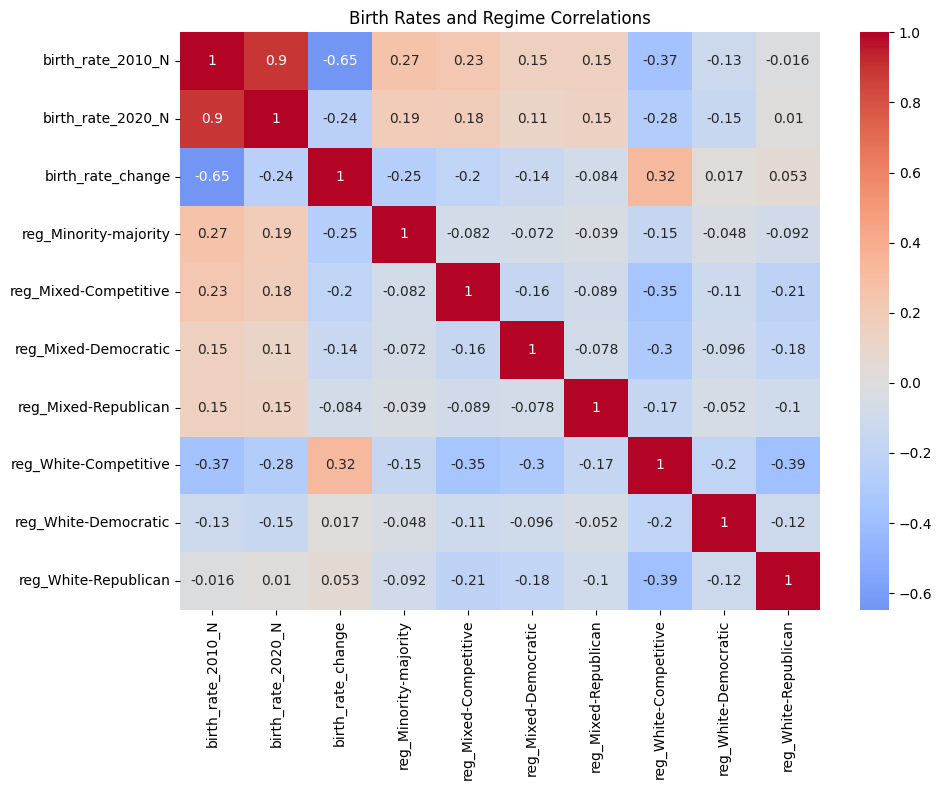

In [26]:
# Heat map

df_A["birth_rate_change"] = (
    df_A["birth_rate_2020_N"] - df_A["birth_rate_2010_N"]
)

df_A.groupby("regime")["birth_rate_change"].mean()

reg_cols = df_A.columns[df_A.columns.str.startswith("reg_")]
df_A[reg_cols] = df_A[reg_cols].astype(int)

df_A.loc[:, df_A.columns.str.startswith("reg_")] = \
    df_A.filter(like="reg_").astype(int)

cols = (
    ["birth_rate_2010_N", "birth_rate_2020_N"] +
    list(df_A.filter(like="reg_").columns)
)

cols = ["birth_rate_2010_N", "birth_rate_2020_N", "birth_rate_change"] + list(regime_dummies.columns)

corr_matrix = df_A[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Birth Rates and Regime Correlations")
plt.tight_layout()
plt.show()

## Regime Summary

In [27]:
# Regime Summary

regime_summary = (
    df_A
    .groupby("regime")[["birth_rate_2010_N", "birth_rate_2020_N"]]
    .mean()
)

regime_summary["pct_change"] = (
    (regime_summary["birth_rate_2020_N"] - regime_summary["birth_rate_2010_N"])
    / regime_summary["birth_rate_2010_N"]
) * 100

regime_summary = regime_summary.sort_values("birth_rate_2010_N", ascending=False)

regime_summary

,birth_rate_2010_N,birth_rate_2020_N,pct_change
regime,,,
Minority-majority,16.120556,12.773889,-20.760244
Mixed-Republican,14.571429,12.244762,-15.967320
Mixed-Competitive,14.069877,11.687654,-16.931365
Mixed-Democratic,13.754531,11.464688,-16.647923
White-Republican,12.700612,10.941735,-13.848762
White-Competitive,11.688657,10.254229,-12.271965
White-Democratic,11.590645,9.784194,-15.585428


## Bar Graph

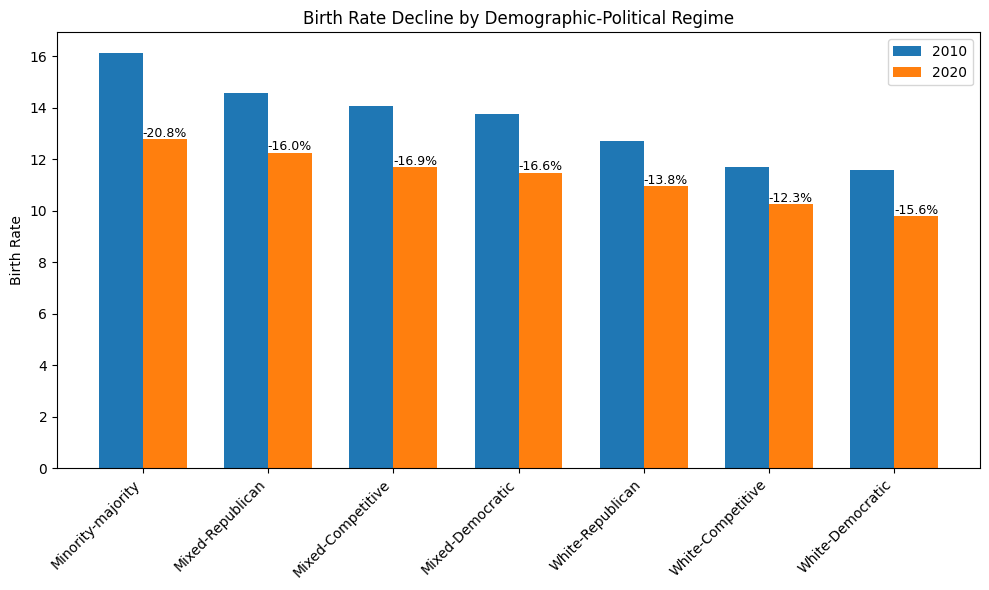

In [28]:
# Bar Graph

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(regime_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(x - width/2,
               regime_summary["birth_rate_2010_N"],
               width,
               label="2010")

bars2 = ax.bar(x + width/2,
               regime_summary["birth_rate_2020_N"],
               width,
               label="2020")

ax.set_xticks(x)
ax.set_xticklabels(regime_summary.index, rotation=45, ha="right")
ax.set_ylabel("Birth Rate")
ax.set_title("Birth Rate Decline by Demographic-Political Regime")
ax.legend()

# Add % drop labels above 2020 bars
for i, v in enumerate(regime_summary["birth_rate_2020_N"]):
    pct = regime_summary["pct_change"].iloc[i]
    ax.text(i + width/2,
            v + 0.1,
            f"{pct:.1f}%",
            ha="center",
            fontsize=9)

plt.tight_layout()
plt.show()

## Regime Analysis

In [29]:
# Regime Analysis

# Subset minority-majority counties
mm = df_A[df_A["reg_Minority-majority"] == 1].copy()

# Count by political group
mm_counts = mm["pol_group"].value_counts()

# Share by political group
mm_share = mm["pol_group"].value_counts(normalize=True)

# Average Democratic vote share
mm_avg_dem = mm["dem2010_P"].mean()

mm_counts, mm_share, mm_avg_dem

(pol_group
 Democratic     11
 Competitive     7
 Name: count, dtype: int64,
 pol_group
 Democratic     0.611111
 Competitive    0.388889
 Name: proportion, dtype: float64,
 np.float64(0.6258212850101238))

Minority-majority counties (n = 18) were predominantly Democratic-leaning, with 61% classified as Democratic and 39% as Competitive under the baseline 2008–2012 vote-share rule. The average Democratic vote share in these counties was 62.6%. No minority-majority counties were classified as Republican.

Due to the small subgroup counts and shared demographic structure, these counties were retained as a unified regime category to preserve statistical stability and avoid sparse cell bias.

## Baseline Model

In [30]:
# Target
y = df_A["birth_rate_2020_N"]

# Overall mean
y_mean = y.mean()

# Predict mean for every observation
baseline_preds = np.full(len(y), y_mean)

# Evaluate
baseline_rmse = np.sqrt(mean_squared_error(y, baseline_preds))
baseline_mae  = mean_absolute_error(y, baseline_preds)

print("Naive Baseline (Predict Overall Mean)")
print("--------------------------------------")
print("RMSE:", round(baseline_rmse, 4))
print("MAE :", round(baseline_mae, 4))

Naive Baseline (Predict Overall Mean)
--------------------------------------
RMSE: 1.8811
MAE : 1.4564


Using the mean of our target variable as a baseline, we record an RMSE of 1.8811 and an MAE of 1.4564.

## Model I - Percent Change Model

In [31]:
# Model I: Percent Change Model

df = df_A.copy()

# Percent change
df["br_pct_change"] = (df["birth_rate_2020_N"] - df["birth_rate_2010_N"]) / df["birth_rate_2010_N"]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["br_pct_change", "birth_rate_2010_N"])

reg_cols = [c for c in df.columns if c.startswith("reg_")]
ref = "reg_White-Competitive"
reg_cols_model = [c for c in reg_cols if c != ref]

X = df[reg_cols_model].astype(int)          # regime-only
y = df["br_pct_change"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=71)

m = LinearRegression().fit(X_train, y_train)
pred = m.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
print("Percent-change model (regime-only)")
print("RMSE:", round(rmse,4), "MAE:", round(mae,4))

coef = dict(zip(X.columns, m.coef_))
print("\nCoefficients vs White-Competitive (in pct-change units):")
for k,v in sorted(coef.items(), key=lambda kv: kv[1]):
    print(f"{k:25s} {v: .4f}")

Percent-change model (regime-only)
RMSE: 0.0645 MAE: 0.051

Coefficients vs White-Competitive (in pct-change units):
reg_Minority-majority     -0.0784
reg_Mixed-Democratic      -0.0511
reg_Mixed-Competitive     -0.0479
reg_Mixed-Republican      -0.0392
reg_White-Democratic      -0.0281
reg_White-Republican      -0.0013


Model I estimates 2020 birth rates by modeling percentage change from 2010 as a function of regime category, allowing different demographic-political groups to exhibit systematically different rates of decline.

## Model II - Excess 2020 Model

In [32]:
# Model II: Excess 2020 Model

df = df_A.copy()
df = df.dropna(subset=["birth_rate_2010_N", "birth_rate_2020_N"]).copy()

# 1 - baseline trajectory model
base = LinearRegression()
X0 = df[["birth_rate_2010_N"]]
y0 = df["birth_rate_2020_N"]
base.fit(X0, y0)

df["br2020_pred_from2010"] = base.predict(X0)
df["excess_2020"] = df["birth_rate_2020_N"] - df["br2020_pred_from2010"]

# 2 - model excess using regimes
reg_cols = [c for c in df.columns if c.startswith("reg_")]
ref = "reg_White-Competitive"
reg_cols_model = [c for c in reg_cols if c != ref]

X = df[reg_cols_model].astype(int)
y = df["excess_2020"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=71)

m = LinearRegression().fit(X_train, y_train)
pred = m.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
print("Excess-2020 model (regimes explain deviation from expected trajectory)")
print("RMSE:", round(rmse,4), "MAE:", round(mae,4))

coef_table = (
    pd.DataFrame({"regime": X.columns, "coef": m.coef_})
      .sort_values("coef")
)
print("\nRegime effects on excess_2020 (vs White-Competitive):")
print(coef_table.to_string(index=False))

Excess-2020 model (regimes explain deviation from expected trajectory)
RMSE: 0.7946 MAE: 0.6043

Regime effects on excess_2020 (vs White-Competitive):
               regime      coef
reg_Minority-majority -0.568533
 reg_White-Democratic -0.346177
 reg_Mixed-Democratic -0.285109
reg_Mixed-Competitive -0.236590
 reg_Mixed-Republican -0.000797
 reg_White-Republican  0.068328


Model II predicts 2020 birth rates by first accounting for expected continuation from 2010 levels and then modeling regime-based deviations from that expected trajectory.

## Model III - Full Interaction Model

In [33]:
# Model III: Full Interaction Model

df = df_A.dropna(subset=["birth_rate_2010_N","birth_rate_2020_N"]).copy()

# Confirm dummies are numeric (0/1) (not True/False)
reg_cols = [c for c in df.columns if c.startswith("reg_")]
for c in reg_cols:
    df[c] = df[c].astype(int)

ref = "reg_White-Competitive"
reg_cols_model = [c for c in reg_cols if c != ref]

# Upgrade code to handle hyphens
terms_main = " + ".join([f'Q("{c}")' for c in reg_cols_model])
terms_int  = " + ".join([f'birth_rate_2010_N:Q("{c}")' for c in reg_cols_model])

formula = f'birth_rate_2020_N ~ birth_rate_2010_N + {terms_main} + {terms_int}'

fit = smf.ols(formula, data=df).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:      birth_rate_2020_N   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     172.8
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          2.26e-175
Time:                        03:16:55   Log-Likelihood:                -616.36
No. Observations:                 514   AIC:                             1261.
Df Residuals:                     500   BIC:                             1320.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

Model III extends the baseline regression by allowing each regime to have its own rate of change from 2010 to 2020, capturing group-specific dynamics rather than assuming a single uniform trend.

## Selected Model (Model III) - Scatterplot and Multiple Regression Lines

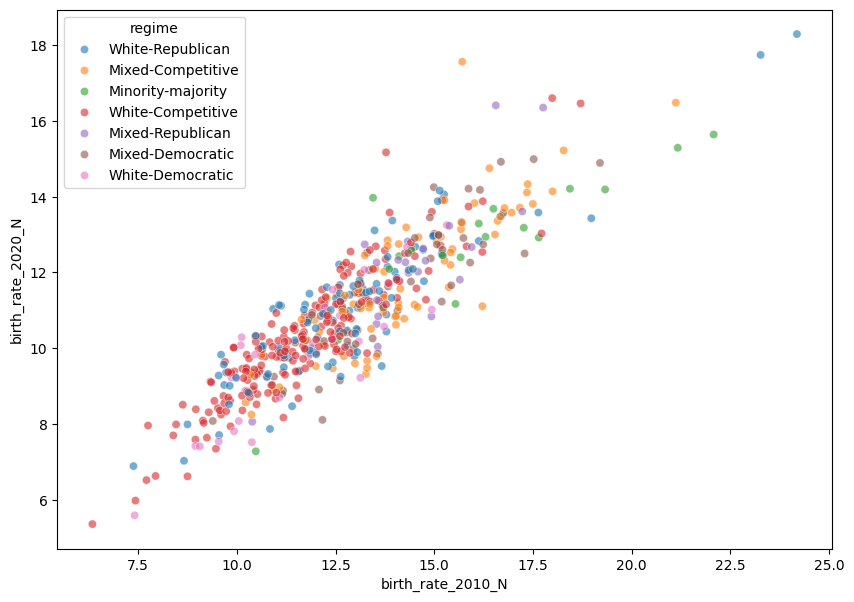

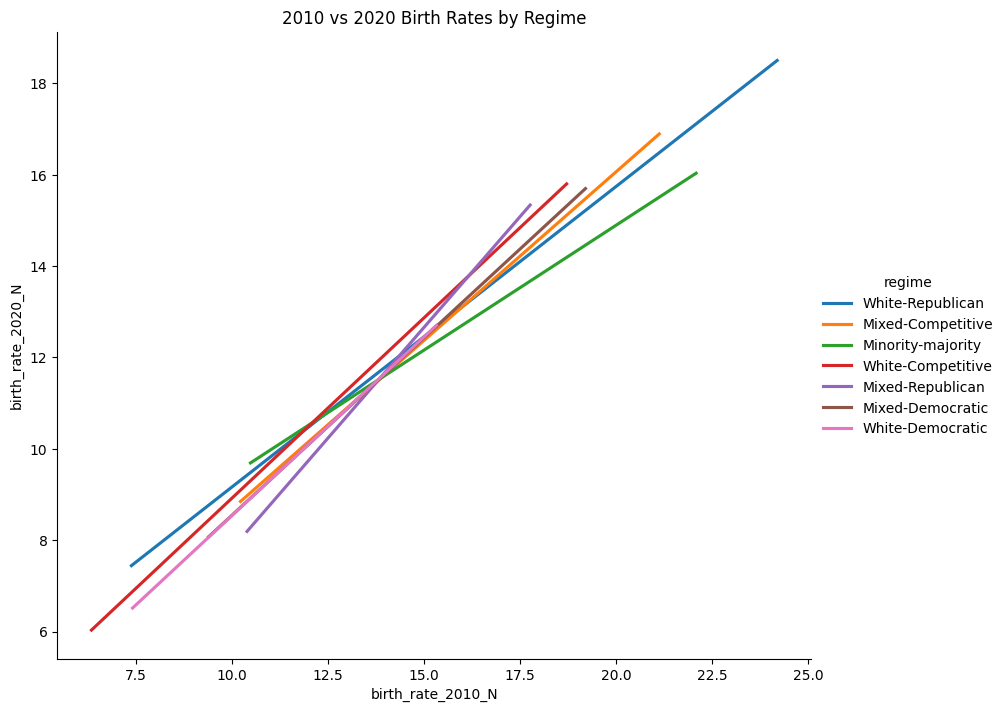

In [34]:
# Model III Graphics

plt.figure(figsize=(10, 7))

# Scatter points colored by regime
sns.scatterplot(
    data=df_A,
    x="birth_rate_2010_N",
    y="birth_rate_2020_N",
    hue="regime",
    alpha=0.6
)

# Add regression line for each regime
sns.lmplot(
    data=df_A,
    x="birth_rate_2010_N",
    y="birth_rate_2020_N",
    hue="regime",
    ci=None,
    height=7,
    aspect=1.2,
    scatter=False
)

plt.title("2010 vs 2020 Birth Rates by Regime")
plt.show()

## Selected Model (Model III) - Train / Test

In [35]:
# White-Competitive (baseline) dropped to avoid dummy trap

X_cols = [
    "birth_rate_2010_N",
    "reg_Minority-majority",
    "reg_Mixed-Competitive",
    "reg_Mixed-Democratic",
    "reg_Mixed-Republican",
    "reg_White-Democratic",
    "reg_White-Republican"
]

X = df_A[X_cols]
y = df_A["birth_rate_2020_N"]

In [36]:
# 80-20 split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 411
Test size: 103


In [37]:
# 5-fold cross validation on training set

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)

    fold_results.append({
        "Fold": fold,
        "RMSE": rmse,
        "MAE": mae
    })

cv_results = pd.DataFrame(fold_results)
cv_results

,Fold,RMSE,MAE
0,1,0.792517,0.607154
1,2,0.870084,0.689295
2,3,0.872703,0.593468
3,4,0.857695,0.683022
4,5,0.855789,0.683799


In [38]:
# Cross-validation summary

print("Cross-Validation Mean Results")
print("--------------------------------")
print("Mean RMSE:", cv_results["RMSE"].mean())
print("Mean MAE :", cv_results["MAE"].mean())
print("Std RMSE :", cv_results["RMSE"].std())

Cross-Validation Mean Results
--------------------------------
Mean RMSE: 0.8497574838619044
Mean MAE : 0.6513476604199626
Std RMSE : 0.03284621630288253


In [39]:
# Final model training on 80%

final_model = LinearRegression()
final_model.fit(X_train, y_train)

LinearRegression()

In [40]:
# Evaluate vs 20% test set

y_test_pred = final_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Test Set Performance")
print("---------------------")
print("RMSE:", round(test_rmse, 4))
print("MAE :", round(test_mae, 4))

Test Set Performance
---------------------
RMSE: 0.795
MAE : 0.6132


## Actual vs Predicted

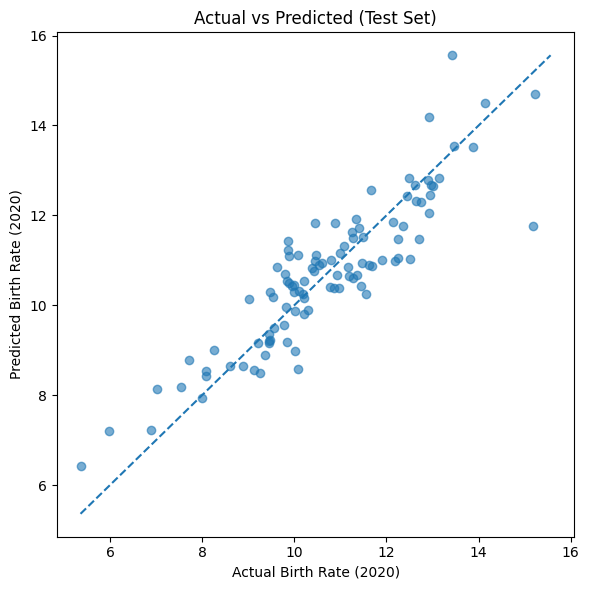

In [41]:
# Actual vs Predicted

# Predictions
y_pred = model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

# 45-degree reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Birth Rate (2020)")
plt.ylabel("Predicted Birth Rate (2020)")
plt.title("Actual vs Predicted (Test Set)")
plt.tight_layout()
plt.show()